In [24]:
import pandas as pd
import numpy as np
import mudata as md

In [25]:
# for list of cis gene/gRNA pairs
sceptre_results_file = "/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/sceptre_results_export.csv"
mudata_file = "/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen.h5mu"
cis_pairs_only=False
chunk_size=2048 # number of genes per file chunk

In [26]:
sceptre_results = pd.read_csv(sceptre_results_file)
sceptre_results

,gene_id,gRNA_id,p_value,skew_t_fit_success,xi,omega,alpha,nu
0,ENSG00000008256,ACTB_TSS,1.684303e-01,True,-0.066602,0.947855,0.126446,3.946003e+01
1,ENSG00000011275,ACTB_TSS,2.010234e-01,True,-0.553322,1.085214,0.737834,8.256523e+01
2,ENSG00000075618,ACTB_TSS,9.916670e-01,True,-0.916371,1.312246,0.889398,1.107978e+03
3,ENSG00000075624,ACTB_TSS,5.007100e-11,True,-0.866612,1.783860,0.968370,9.667537e+04
4,ENSG00000086232,ACTB_TSS,2.941922e-01,True,0.527563,0.990631,-0.329564,1.791409e+01
...,...,...,...,...,...,...,...,...
629510,ENSG00000066827,chr8.3446_top_two,1.372567e-01,True,-0.654953,1.099360,1.043521,5.741392e+00
629511,ENSG00000131773,chr8.3446_top_two,1.267156e-01,True,-1.078687,1.427121,3.831266,1.427994e+07
629512,ENSG00000022567,chr8.3533_top_two,4.683269e-01,True,-0.159764,0.940689,0.175429,2.627980e+01
629513,ENSG00000104472,chr8.3533_top_two,1.477046e-01,False,NaN,NaN,NaN,NaN


In [ ]:
mdata = md.read(mudata_file)
mdata 

In [28]:
mdata['grna'].var.value_counts('element').sort_values()

element
pos_control_Klannchr1_HS4                   1
pos_control_Klannchr1_HBG1_HBG1_tss_both    1
pos_control_Klannchr1_HS3                   1
pos_control_Klannchr_HS1                    1
pos_control_mosaic_HB_HBE1_tss_B            1
                                           ..
scrambled_23                                2
scrambled_24                                2
scrambled_14                                2
scrambled_15                                2
chr2.183_second_two                         2
Length: 6598, dtype: int64

In [29]:
mdata['grna']

AnnData object with n_obs × n_vars = 207324 × 13189
    var: 'Spacer', 'Target_Site', 'chr.candidate_enhancer', 'start.candidate_enhancer', 'stop.candidate_enhancer', 'Category', 'element'
    uns: 'elements'
    varm: 'element_targeted'

In [30]:
sceptre_results = sceptre_results.merge(mdata['rna'].var.reset_index(), on = 'gene_id')

In [31]:
sceptre_results.value_counts('gRNA_id')

gRNA_id
scrambled_9           10560
random_21             10560
scrambled_1           10560
random_9              10560
random_8              10560
                      ...  
chr7.3068_top_two         1
chr4.1131_top_two         1
chr20.2633_top_two        1
chr15.3474_top_two        1
chr3.2964_top_two         1
Length: 6542, dtype: int64

In [32]:
sceptre_results.value_counts('gene_id')

gene_id
ENSG00000197279    145
ENSG00000198315    144
ENSG00000112812    141
ENSG00000124657    139
ENSG00000124635    139
                  ... 
ENSG00000028277     52
ENSG00000006831     52
ENSG00000132953     52
ENSG00000107643     52
ENSG00000107485     52
Length: 10560, dtype: int64

In [33]:
# mdata['rna']

In [34]:
# mdata['grna'].var.assign(start_10mb = lambda x:x['start.candidate_enhancer'].astype(float)//1e7).value_counts(['chr.candidate_enhancer', 'start_10mb'])

<AxesSubplot: >

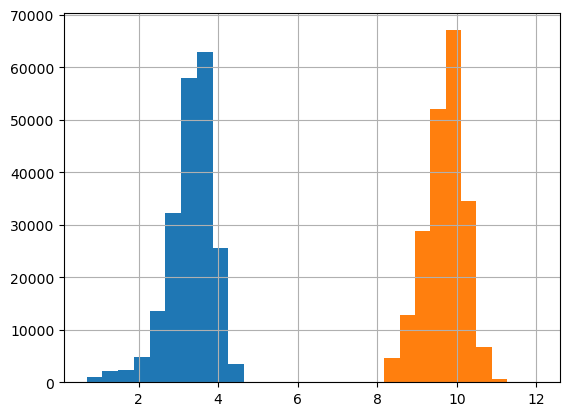

In [35]:
mdata['rna'].obs=mdata['rna'].obs.assign(
    log1p_guide_count=np.log1p(mdata['rna'].obs["guide_count"]),
    log1p_gene_count= np.log1p(mdata['rna'].obs["total_umis"])
)

mdata['rna'].obs["log1p_guide_count"].hist()
mdata['rna'].obs["log1p_gene_count"].hist()


In [36]:
from math import ceil
n_genes = mdata['rna'].shape[1]
# mdata_subset = md.MuData({, 'grna':mdata['grna']})
for i in range(0,ceil(n_genes/chunk_size)):
    # divide RNA count matrix into chunks of size chunk_size
    start = i*chunk_size
    end = min(start+chunk_size, n_genes)
    print(start, end)
    rna_adata_subset = mdata['rna'][:,start:end]

    if cis_pairs_only:
        chunk_elements = pd.merge(sceptre_results, rna_adata_subset.var.reset_index())['gRNA_id'].unique()
        chunk_elements
        grna_adata_subset = mdata['grna'][:,mdata['grna'].var['element'].isin(chunk_elements)]
        grna_adata_subset.varm['element_targeted']
        
        selected_element_idx = np.where(grna_adata_subset.varm['element_targeted'].sum(axis=0)>0)[1]
        selected_elements = grna_adata_subset.uns['elements'][selected_element_idx]
        grna_adata_subset.varm['element_targeted'] = np.array(grna_adata_subset.varm['element_targeted'][:,selected_element_idx].todense())
        grna_adata_subset.uns['elements']=selected_elements
        grna_adata_subset
    else:
        grna_adata_subset = mdata['grna'].copy()
        grna_adata_subset.varm['element_targeted'] = mdata['grna'].varm['element_targeted'].toarray()
    mdata_subset = md.MuData({"rna":rna_adata_subset, "grna":grna_adata_subset})
    print(mdata_subset)
    chunk_path = f"/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.{i:02d}.h5mu"
    mdata_subset.write(chunk_path)
    print(chunk_path)
# mdata['grna'].var.merge(chunk_grnas.rename(column}))

0 2048
MuData object with n_obs × n_vars = 207324 × 15237
  2 modalities
    rna:	207324 x 2048
      obs:	'sample', 'total_umis', 'Size_Factor', 'read_count', 'umi_count', 'proportion', 'guide_count', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito', 'log1p_guide_count', 'log1p_gene_count'
      var:	'gene_name', 'contig', 'start', 'end'
    grna:	207324 x 13189
      var:	'Spacer', 'Target_Site', 'chr.candidate_enhancer', 'start.candidate_enhancer', 'stop.candidate_enhancer', 'Category', 'element'
      uns:	'elements'
      varm:	'element_targeted'
/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.00.h5mu
2048 4096
MuData object with n_obs × n_vars = 207324 × 15237
  2 modalities
    rna:	207324 x 2048
      obs:	'sample', 'total_umis', 'Size_Factor', 'read_count', 'umi_count', 'proportion', 'guide_count', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito', 'log1p_guide_count', 'log1p_gene_c